In [1]:
%matplotlib inline
# %matplotlib notebook
from sklearn.model_selection import train_test_split
import numpy as np
import qutip as qt
from entVAE import vae_utils 
from scipy.stats import linregress
from qiskit.quantum_info import Statevector, DensityMatrix
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1779100995.159838   39945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779100995.192043   39945 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779100996.316058   39945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

In [3]:
n_angle = 101
n_samples = 1000
scan_arr = np.linspace(0, np.pi, n_angle)
alpha_arr = np.zeros(101000)
cnt = 0
for theta in scan_arr:
        for _ in (range(n_samples)):
            alpha_arr[cnt] = theta
            cnt += 1

In [4]:
colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
markers = ["o", "s", "^", "D", "v", "p"]

MS = 5 
LW = 1.2 
MW = 0.5

# Noisy Dataset  $0.75\beta$

Load Dataset

In [5]:
rho_arr_noisy = np.load('../data/unitary_4x4_101_1000.npy', mmap_mode="r")
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(rho_arr_noisy, alpha_arr, random_state=42)
concurrence_noisy_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noisy])

Load trained VAE and define Hyperparameters:

In [6]:
batch_size = 64
beta = 0.75
learning_rate = 0.0001
lat_dim = 1
hidden_act = "tanh"
final_act = "linear"

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, hidden_act, final_act)
encoder.load_weights("../data/encoder_noise_075beta.h5")
decoder.load_weights("../data/decoder_noise_075beta.h5")

vae_noisy = vae_utils.VAE(encoder, decoder, beta)
vae_noisy.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

z_mean_noisy, z_log_var_noisy, z_noisy = vae_noisy.encoder.predict(X_test_noisy)

790/790 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step


# Generalization

In [7]:
test_01 = np.load("../data/test_arr_01.npy")
test_02 = np.load("../data/test_arr_02.npy")
test_12 = np.load("../data/test_arr_12.npy")

test_conc_01 = np.array([qt.concurrence(qt.Qobj(dm,dims=[[2,2],[2,2]])) for dm in np.array(test_01)])
test_conc_02 = np.array([qt.concurrence(qt.Qobj(dm,dims=[[2,2],[2,2]])) for dm in np.array(test_02)])
test_conc_12 = np.array([qt.concurrence(qt.Qobj(dm,dims=[[2,2],[2,2]])) for dm in np.array(test_12)])

max_angle = 2*np.arccos(1/np.sqrt(3)) 
scan_arr = np.linspace(0,max_angle,101)

fit_x_01 = test_conc_01.flatten()
fit_y_01 = -vae_noisy.encoder.predict(np.reshape(np.array(test_01),(101,16)))[0].flatten()
fit_obj_01 = np.polyfit(fit_x_01, fit_y_01, 1)
fit_pred_01 = np.poly1d(fit_obj_01)
fitted_y_01 = fit_pred_01(fit_x_01)

fit_x_02 = test_conc_02.flatten()
fit_y_02 = -vae_noisy.encoder.predict(np.reshape(np.array(test_02),(101,16)))[0].flatten()
fit_obj_02 = np.polyfit(fit_x_02, fit_y_02, 1)
fit_pred_02 = np.poly1d(fit_obj_02)
fitted_y_02 = fit_pred_01(fit_x_02)

fit_x_12 = test_conc_12.flatten()
fit_y_12 = -vae_noisy.encoder.predict(np.reshape(np.array(test_12),(101,16)))[0].flatten()
fit_obj_12 = np.polyfit(fit_x_12, fit_y_12, 1)
fit_pred_12 = np.poly1d(fit_obj_12)
fitted_y_12 = fit_pred_01(fit_x_12)

slope, intercept, r_value, p_value, std_err = linregress(fit_x_01, fit_y_01)
print(r_value**2)

slope, intercept, r_value, p_value, std_err = linregress(fit_x_02, fit_y_02)
print(r_value**2)

slope, intercept, r_value, p_value, std_err = linregress(fit_x_12, fit_y_12)
print(r_value**2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
0.9989828155911186
0.9993603152347167
0.9993603152347167


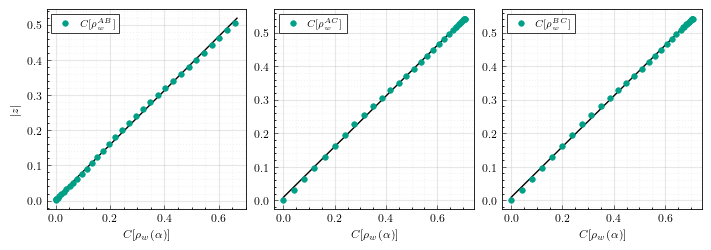

In [ ]:

fig, axs = plt.subplots(
    1, 3,
    figsize=(7.0, 2.4),
    constrained_layout=True
)

datasets = [
    (test_conc_01, fit_y_01, fit_pred_01, "C0", "$C[\\rho^{AB}_w]$"),
    (test_conc_02, fit_y_02, fit_pred_02, "C1", "$C[\\rho^{AC}_w]$"),
    (test_conc_12, fit_y_12, fit_pred_12, "C3", "$C[\\rho^{BC}_w]$")
]

for ax, (x, y, fit_fn, color, label) in zip(axs, datasets):
    
    # fitted line
    ax.plot(x, fit_fn(x), c="black", lw=1)

    # data
    ax.plot(
        x[::3],
        np.abs(y[::3]),
        "o",
        c=colors[2],
        label=label,
        markersize=4,
        markeredgewidth=0.5,
            zorder=3
    )

    
    # square aspect
    ax.set_box_aspect(1)

    # labels
    ax.set_xlabel("$C[\\rho_w(\\alpha)]$")
    ax.set_ylabel("$|z|$")

    # grid
    ax.grid(True, which="major", linestyle="-", alpha=0.3)
    ax.grid(True, which="minor", linestyle=":", alpha=0.15)

    ax.tick_params(direction="in", which="both", labelsize=8)
    ax.tick_params(which="major", length=3)
    ax.tick_params(which="minor", length=1.5)
    ax.minorticks_on()

    legend = ax.legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=1,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
        )
    legend.get_frame().set_linewidth(0.6)



# optional: remove duplicate y-labels
for ax in axs[1:]:
    ax.set_ylabel("")

# plt.savefig("fig_exp6_final.pdf",bbox_inches="tight",pad_inches=0.1)